In [18]:
import json
import os
from sympy import symbols, simplify, sin, expand
#from pysr import PySRRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sklearn.model_selection import train_test_split

In [19]:
import pymc as pm
import arviz as az

In [20]:
x = np.linspace(-2, 2, 700)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
noise = rng.normal(size=x.shape, scale = 0.05)
y = np.cos(x) + noise 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

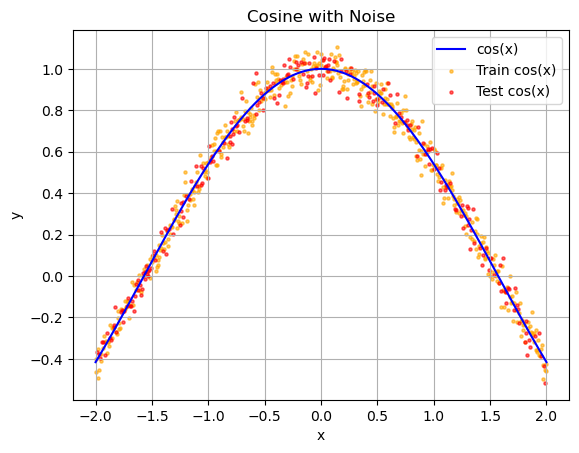

In [21]:
plt.plot(x, np.cos(x), label='cos(x)', color='blue')
plt.scatter(x_train, y_train, s=5, alpha=0.6, label='Train cos(x)', color='orange')
plt.scatter(x_test, y_test, s=5, alpha=0.6, label='Test cos(x)', color='red')
plt.legend()
plt.title('Cosine with Noise')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [5]:
x_train.size, x_test.size

(469, 231)

In [5]:
# # Save to CSV in a format SISSO++ expects
# df = pd.DataFrame({"sample_id": [f"s{i+1}" for i in range(len(x))], 'f1': x, 'target': y})
# df.to_csv("/home/paolo/Thesis/Test_uncertainty/data/cosine_data.csv", index=False)
# data_file = "/home/paolo/Thesis/Test_uncertainty/data/cosine_data.csv"

# os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [6]:
# # Try the fit with the exact functional form
# cos_json = {
#     'data_file': data_file,
#      'property_key': 'target',
#      'desc_dim': 1,
#      'n_sis_select': 10,
#      'max_rung': 2,
#      'calc_type': 'regression',
#      'min_abs_feat_val': 1e-05,
#      'max_abs_feat_val': 1e8,
#      'n_residual': 10,
#      'n_models_store': 10,
#      'leave_out_frac': 0.0,
#      'leave_out_inds': [],
#      'opset': ['add', 'sub', 'mult', 'div', 'cos', 'sin', 'sqrt', 'sq']
# }
# json.dump(cos_json, open("/home/paolo/Thesis/Test_uncertainty/data/cos.json", "w"), indent=4)

In [7]:
# # Try the fit with the exact functional form
# cos_json = {
#     'data_file': data_file,
#      'property_key': 'target',
#      'desc_dim': 1,
#      'n_sis_select': 10,
#      'max_rung': 2,
#      'calc_type': 'regression',
#      'min_abs_feat_val': 1e-05,
#      'max_abs_feat_val': 1e8,
#      'n_residual': 10,
#      'n_models_store': 10,
#      'leave_out_frac': 0.0,
#      'leave_out_inds': [],
#      'opset': ['add', 'sub', 'mult', 'div', 'cos', 'sin', 'sqrt', 'sq']
# }
# json.dump(cos_json, open("/home/paolo/Thesis/Test_uncertainty/data/cos.json", "w"), indent=4)

In [22]:
# Extract the formulas and the values of the parameters from the SISSO output
formulas = []
a0_list = []
c0_list = []
models_stored = 10
for i in range(models_stored):
    filename = f'./models_cosine/train_dim_1_model_{i}.dat'
    with open(filename, 'r') as f:
        line1 = next(f)               # First line
        for _ in range(4): next(f)    # Skip lines 2 to 5
        line6 = next(f)               # Sixth line
        formula = line1.replace('#', '').strip()
        # Split line6 by spaces
        parts = line6.strip().split()
        a0_i = parts[3].rstrip(',')
        c0_i = parts[4].rstrip(',')

        formulas.append(formula)
        a0_list.append(a0_i)
        c0_list.append(c0_i)
        print(formula, a0_i, c0_i)

c0 + a0 * cos(f1) 1.001325831302119e+00 -1.256782741748731e-03
c0 + a0 * (sin(f1) / f1) 2.660682304939602e+00 -1.681643326882762e+00
c0 + a0 * (cos(f1) - (f1^2)) 2.717475659877717e-01 6.929549500655449e-01
c0 + a0 * (f1^2) -3.720431943703498e-01 9.502941844118713e-01
c0 + a0 * (sin(f1) * f1) -6.966557323989504e-01 1.060213819741886e+00
c0 + a0 * (cos(f1) + (f1^2)) -5.869170069366709e-01 1.503758358056813e+00
c0 + a0 * cos((f1^2)) 5.695328649434339e-01 3.218424044159163e-01
c0 + a0 * ((f1^2)^2) -9.636360803755634e-02 7.630870787141347e-01
c0 + a0 * (sin(f1)^2) -1.108088324828590e+00 1.111630451799396e+00
c0 + a0 * (sin(f1) - (f1^2)) 2.633141470454703e-01 8.047410709589261e-01


In [23]:
# Store the numerical values of the parameters into np arrays
a0 = np.array(a0_list, dtype=float)
c0 = np.array(c0_list, dtype=float)
a0, c0

(array([ 1.00132583,  2.6606823 ,  0.27174757, -0.37204319, -0.69665573,
        -0.58691701,  0.56953286, -0.09636361, -1.10808832,  0.26331415]),
 array([-1.25678274e-03, -1.68164333e+00,  6.92954950e-01,  9.50294184e-01,
         1.06021382e+00,  1.50375836e+00,  3.21842404e-01,  7.63087079e-01,
         1.11163045e+00,  8.04741071e-01]))

In [24]:
a0_simb, c0_simb, x_simb = sp.symbols('a0 c0 f1')
symbol_map = {'x': x_simb, 'a0': a0_simb, 'c0': c0_simb}

# Converts the equtions (stored into the 'Feature Expression' column of df) from strings into sympy objects
sympy_exprs = [sp.sympify(f, locals=symbol_map) for f in formulas]
# Builds Python functions starting from the sympy expressions pruning the constants
functions = [sp.lambdify((x_simb), (expr - c0_simb)/a0_simb, modules='numpy') for expr in sympy_exprs]

In [25]:
sympy_exprs

[a0*cos(f1) + c0,
 a0*sin(f1)/f1 + c0,
 a0*(-f1**2 + cos(f1)) + c0,
 a0*f1**2 + c0,
 a0*f1*sin(f1) + c0,
 a0*(f1**2 + cos(f1)) + c0,
 a0*cos(f1**2) + c0,
 a0*f1**4 + c0,
 a0*sin(f1)**2 + c0,
 a0*(-f1**2 + sin(f1)) + c0]

In [26]:
for expr in sympy_exprs:
    print(sp.simplify((expr - c0_simb)/a0_simb))

cos(f1)
sin(f1)/f1
-f1**2 + cos(f1)
f1**2
f1*sin(f1)
f1**2 + cos(f1)
cos(f1**2)
f1**4
sin(f1)**2
-f1**2 + sin(f1)


In [27]:
# In each column are stacked data for each of the 10 different formulas
Phi = np.column_stack([f(x_train) for f in functions])
Phi_test = np.column_stack([f(x_test) for f in functions])
Phi_tot = np.column_stack([f(x) for f in functions])
n_features = Phi[:,0].shape
n_features

(469,)

In [11]:
# basic_model = pm.Model()

# with basic_model:
#     # Priors for unknown model parameters
#     # Normal weights
#     alpha = pm.Normal("c0", mu=c0[3], sigma=10)
#     beta = pm.Normal("a0", mu=a0[3], sigma=10)
#     # Sigma is positively defined and normally distributed --> HalfNormal
#     sigma = pm.HalfNormal("sigma", sigma=1)

#     # Expected value of outcome, Linear model
#     mu = alpha + beta * Phi[:, 3]

#     # Likelihood (sampling distribution) of observations --> normal distribution with the deterministic equation as mean and sigma as variance
#     y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
#     # draws 2000 posterior samples from the unnormalized posterior distribution computed as likelihood x prior using sequential montecarlo method
#     idata = pm.smc.sample_smc()
#     # idata = pm.sample()

In [33]:
traces = []
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = Phi[:, i]

        # Priors, Che valori di sigma potrei usare? 10 forse è un po' troppo
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc()
        #trace = pm.sample()
        traces.append(trace)

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


...

Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

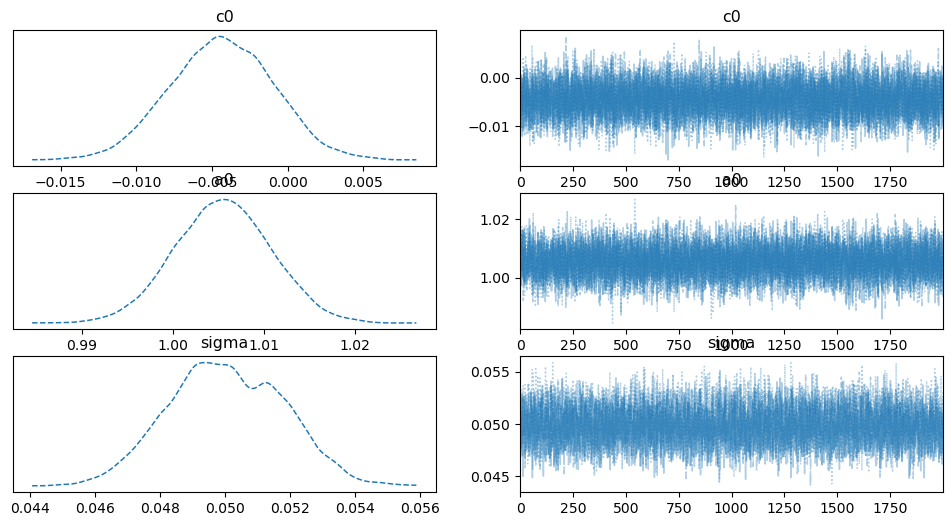

In [34]:
az.plot_trace(traces[0], combined=True);

In [27]:
az.summary(traces[0], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,-0.004,0.003,-0.011,0.002,0.0,0.0,11743.532,11499.740,1.000
a0,1.005,0.005,0.996,1.015,0.0,0.0,11613.473,11642.514,1.000
sigma,0.050,0.002,0.047,0.053,0.0,0.0,9484.056,9365.432,1.006


In [29]:
c0[0], a0[0]

(np.float64(-0.001256782741748731), np.float64(1.001325831302119))

We have used Sequential MonteCarlo as a sampling technique since it is able to provide us a robust estimate of the evidence, also called marginal likelihood.
In Bayes' formula:
$$
    p(\theta | D) = \frac{p(D|\theta) \ p(\theta)}{p(D)}
$$
where the evidence is defined as $p(D) = \int d\theta \ p(d|\theta) p(\theta)$, obtained marginalizing the likelihood thus the name.

Actually for numerical reasons the returned value is the log marginal likelihood (this helps to avoid underflow), we thus need to exponentiate to get the marginal likelihood.

In [35]:
traces[i].sample_stats["log_marginal_likelihood"]

<xarray.DataArray 'log_marginal_likelihood' (chain: 1, draw: 6)> Size: 48B
array([[list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-40.20704789311624)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-42.442233788943064)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-40.594147803248205)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-40.319317282566686)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-36.73921666747724)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-38.69028502828318)])]],
      dtype=object)
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 48B 0 1 2 3 4 5

In [36]:
# log marginal likelihood for model 0: 6 chains and 11 draws per chain
traces[1].sample_stats["log_marginal_likelihood"].values 

array([[list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(686.669736911384)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(686.4353925843174)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(675.814251571431)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(682.8156461619631)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(675.9430571214016)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(689.4301668618455)])]],
      dtype=object)

In [37]:
traces[0].sample_stats["log_marginal_likelihood"].values 

array([[list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(720.8884882801483)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(717.2631892097837)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(713.0901065302239)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(701.6891643660015)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(715.6280613901763)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(695.561302159387)])]],
      dtype=object)

In [38]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[720.88848828 717.26318921 713.09010653 701.68916437 715.62806139
 695.56130216]
[686.66973691 686.43539258 675.81425157 682.81564616 675.94305712
 689.43016686]
[631.55375314 633.59401032 621.57952057 616.24171781 625.50005302
 565.57721186]
[575.3134267  577.62302471 571.73170514 561.19442703 550.355088
 530.58612165]
[476.36756033 477.92197275 479.06218819 476.68630603 479.18617522
 477.10962559]
[461.05586009 448.5919152  462.78473759 462.38365627 460.11235078
 456.52563234]
[354.63225943 351.77587108 355.62261611 353.6458046  351.00113512
 346.73081849]
[121.76020378 126.33586562 123.45468291 120.16913912 120.24862174
 123.899156  ]
[56.38560333 56.71119634 55.26482357 56.08351846 55.93543825 57.28287578]
[-40.20704789 -42.44223379 -40.5941478  -40.31931728 -36.73921667
 -38.69028503]


In [39]:
log_marginal_likelihoods

[np.float64(710.6867186559534),
 np.float64(682.851375202057),
 np.float64(615.6743777876449),
 np.float64(561.1339655380416),
 np.float64(477.72230468636235),
 np.float64(458.5756920460869),
 np.float64(352.23475080412317),
 np.float64(122.64461152684534),
 np.float64(56.27724262257858),
 np.float64(-39.83204141060576)]

In [40]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(710.6867186559534), np.int64(0))

We have found the equation with the highest marginal likelihood (for $\beta = 1$) and we are going to use it as a benchmark to gauge the quality of the other models, i.e. how "badly" do they perform against the benchmark.

In [41]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(8.151995590631667e-13),
 np.float64(5.4533660258094173e-42),
 np.float64(1.1221852794881243e-65),
 np.float64(6.680985561427513e-102),
 np.float64(3.232751458890812e-110),
 np.float64(2.119768013794478e-156),
 np.float64(4.135783031798922e-256),
 np.float64(6.216925363130879e-285),
 np.float64(0.0)]

In [42]:
np.argsort(ml_diff)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

# Safe Bayes

$\Pi(\theta \mid z_{i-1}, \eta) \propto p(\theta)\prod_{j=1}^{i-1} p(z_j \mid \theta)^{\eta}.$

$r := \ell_{\Pi\mid z_{i-1}, \eta}(z_i)
    = \mathbb{E}_{\theta \sim \Pi\mid z_{i-1}, \eta} 
      \big[\, \ell_\theta(z_i) \,\big] = \int \ell_\theta(z_i) \, \Pi_{\mid z_{i-1}, \eta}(\theta) \, d\theta.$ posterior of previous points * loss

In [49]:
def log_likelihood_single(theta, x, y):
    """
    Return log p(y | x, theta).
    """
    # Fixed model
    f = Phi_tot[:, 0]
    
    # Priors
    # c0_coeff = pm.Normal("c0", mu=c0[0], sigma=10)
    # a0_coeff = pm.Normal("a0", mu=a0[0], sigma=10)
    # sigma = pm.HalfNormal("sigma", sigma=2)
    c0_coeff, a0_coeff, sigma = theta
    # Linear parametrization
    mu = c0_coeff + a0_coeff * f
    return pm.logp(pm.Normal.dist(mu=mu, sigma=sigma), y)

In [50]:
# -------------------------------------------------------------------
# Loss = negative log-likelihood (log-loss)
# -------------------------------------------------------------------

def loss_fn(theta_samples, x, y):
    """
    r_i = E_theta[-log p(y | x, theta)]
    """
    log_liks = np.array([log_likelihood_single(t, x, y) for t in theta_samples])
    return -np.mean(log_liks)

In [48]:
for i in range(0, len(x)):
    z_prev = (x[:i], y[:i])
#z_prev

In [72]:
# -------------------------------------------------------------------
# Main generalized Bayesian updating loop
# -------------------------------------------------------------------
eta = 1/2
s_eta = 0.0

for i in range(1, len(x)):
    data_prev = [(x[:i], y[:i])]     # [(x1, y1), ..., (x_{i−1}, y_{i−1})]
    x_i, y_i = x[i], y[i]    # the current point (xi, yi)

    # -------------------------
    # Build generalized posterior
    # -------------------------
    with pm.Model() as model:

        c0_coeff = pm.Normal("c0", mu=c0[0], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[0], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)
        theta = pm.Deterministic("theta", pm.math.stack([c0_coeff, a0_coeff, sigma]))
        # compute total log-likelihood for past points
        log_like = 0
        print(data_prev)
        for (x, y) in data_prev:
            log_like += log_likelihood_single(theta, x, y)
        print('2')
        # power posterior scale
        pm.Potential("scaled_ll", eta * log_like)

        # sample generalized posterior
        print('2')
        trace = pm.smc.sample_smc(draws = 2000, chains=1, threshold = 0.3) 
        theta_samples = trace.posterior["theta"].stack(sample=("chain", "draw")).values.T
        print('2')
    # -------------------------
    # Posterior-expected log-loss at step i
    # -------------------------
    r = loss_fn(theta_samples, x_i, y_i)
    s_eta += r

    print(f"i={i}, r={r:.4f}, cumulative s_eta={s_eta:.4f}")

In [64]:
print(data_prev)

(array([-2.]), array([-0.40091098]))


# Tempering

In [23]:
beta = np.array([1/8, 1/4, 1/2])
beta

array([0.125, 0.25 , 0.5  ])

In [24]:
traces_temp = []
for i in range(models_stored):
    traces_i = []
    for j in beta.round(2):
        with pm.Model() as model:
            # Select the i-th column
            f = Phi[:, i]
    
            # Priors
            c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
            a0_coeff = pm.Normal("a0", mu=a0[i], sigma=10)
            sigma = pm.HalfNormal("sigma", sigma=2)
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, y)

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws = 2000, threshold = 0.3)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 6 chains in 6 jobs


...

Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

In [25]:
traces_temp[0][1].sample_stats["log_marginal_likelihood"].values

array([[list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(169.58323385380928)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(177.51188125765475)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(173.87619376829457)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(161.96405131426044)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(158.7174603207811)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(168.2523951090798)])]],
      dtype=object)

In [27]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

[71.19380618 78.95686134 70.44731549 56.1995241  63.18718026 63.9417245 ]
[169.58323385 177.51188126 173.87619377 161.96405131 158.71746032
 168.25239511]
[372.81970875 364.64569303 361.29223249 340.76665427 329.80177235
 334.94113622]
[70.83135041 70.23613302 79.94659958 55.57611451 68.54394874 60.87725354]
[170.89427681 167.20870946 156.98918261 161.27455689 171.17011365
 162.93000281]
[353.57095817 360.20463595 349.81540049 357.40578994 352.5667793
 355.81379138]
[66.4868894  47.14973908 50.18155065 49.54216315 39.05360587 17.15466889]
[150.70064611 133.3286116  101.01330218 141.76800201 137.21274255
 121.41438498]
[315.96596297 328.63372609 304.26310489 291.81500423 295.27666713
 299.3281965 ]
[50.37442831 59.48781737 43.09221062 33.3581266  32.42246262 37.96574757]
[135.0567908  142.55929921 114.69979663 103.97897206 131.49431553
 116.04815172]
[305.83238267 296.7498911  297.23782021 238.45881452 271.44992766
 232.39044628]
[38.3231518  43.04260015 39.35514652 36.01086036 34.44387

In [28]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [29]:
log_marginal_likelihoods_temp # dim = (models_select=10, len(beta) = 4)

array([[ 67.32106864, 168.31753594, 350.71119952],
       [ 67.66856663, 165.07780704, 354.89622587],
       [ 44.92810284, 130.90628157, 305.88044363],
       [ 42.78346551, 123.97288766, 273.68654707],
       [ 39.45349488, 101.63041164, 240.43759185],
       [ 32.95928764, 104.25035353, 229.70390145],
       [ 24.29031573,  73.0159895 , 171.99025918],
       [ -4.53174262,  15.27996588,  53.48051738],
       [ -6.95883093,   3.28170444,  23.45826324],
       [-20.51726508, -22.97409061, -27.27487737]])

In [30]:
log_marginal_likelihoods, log_marginal_likelihoods_temp.T[2]

([np.float64(770.9956099769265),
  np.float64(740.3336041773526),
  np.float64(679.295061306275),
  np.float64(628.3964283682618),
  np.float64(518.660665247656),
  np.float64(504.1996580435836),
  np.float64(374.88951911920225),
  np.float64(134.5882077354905),
  np.float64(67.69331358299486),
  np.float64(-34.7688747983183)],
 array([350.71119952, 354.89622587, 305.88044363, 273.68654707,
        240.43759185, 229.70390145, 171.99025918,  53.48051738,
         23.45826324, -27.27487737]))

In [31]:
ml_diff

[np.float64(1.0),
 np.float64(4.8268085923171924e-14),
 np.float64(1.4960900163668834e-40),
 np.float64(1.1747955787939557e-62),
 np.float64(2.584198753817648e-110),
 np.float64(1.3551590858431857e-116),
 np.float64(9.403953916448616e-173),
 np.float64(4.090505341963533e-277),
 np.float64(3.6282196094625383e-306),
 np.float64(0.0)]

In [35]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

1
0
1


In [36]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [37]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[7.06453435e-001, 1.00000000e+000, 1.33027693e-010,
        1.55789399e-011, 5.57635010e-013, 8.43240901e-016,
        1.44898870e-019, 4.40356183e-032, 3.88806073e-033,
        5.02782215e-039],
       [1.00000000e+000, 3.91745140e-002, 5.65586023e-017,
        5.51269483e-020, 1.09181713e-029, 1.49960268e-028,
        4.08379814e-042, 3.44054943e-067, 2.11762505e-072,
        8.37726309e-084],
       [1.52218048e-002, 1.00000000e+000, 5.16079072e-022,
        5.38374672e-036, 1.95545055e-050, 4.26249934e-055,
        3.67238293e-080, 1.24974394e-131, 1.14372532e-144,
        1.05973852e-166]])

In [38]:
# Indices corresponding to the entries sorted in ascending order 
np.argsort(ml_diff_temp.T)

array([[9, 8, 7, 6, 5, 4, 3, 2, 0, 1],
       [9, 8, 7, 6, 4, 5, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 0, 1]])

The top scoring equations seem to retain their classification for different values of beta, i.e. for different weights of the likelihood.

# Calibration

In [39]:
traces[0].posterior['c0'].mean().values

array(-0.00122417)

In [38]:
Phi.shape

(469, 10)

In [ ]:
# y_mean = []
# for m in range(models_stored):
#     # Computes y with the posterior mean values of the parameters c0, a0 and sigma_0
#     y_mean.append(traces[m].posterior['c0'].mean().values + traces[m].posterior['a0'].mean().values * Phi[:, m])
# # Stores the values of c0_post_mean + a0_post_mean * Phi, shape (500, 10) each column stores a different model
# y_mean = np.array(y_mean).T
# y_mean.shape

In [39]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
sigma_samples_list = []
for m in range(models_stored):
# Draws 50 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces[m].posterior['a0'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

In [40]:
c0_samples.shape

(200, 10)

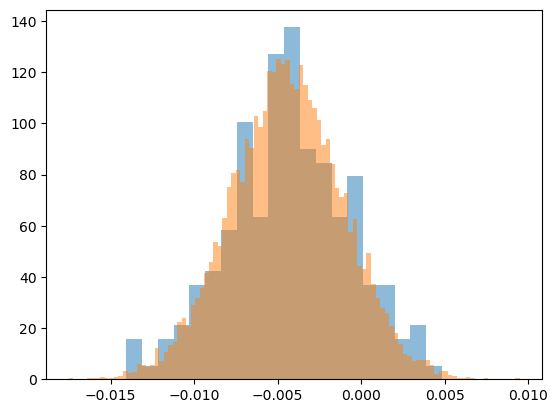

In [41]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [42]:
c0_samples.shape, a0_samples.shape, sigma_samples.shape

((200, 10), (200, 10), (200, 10))

In [79]:
inputs = 700
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 500 points for each of the 10 formulas
        y_emp[i, m] = np.mean(c0_samples[:,m] + Phi_tot[i, m] * a0_samples[:,m])
# Empirical mean over the models
y_emp

array([[-0.42275951, -0.47723543, -0.51058653, ..., -0.76789751,
         0.19778298, -0.50409002],
       [-0.41752073, -0.4705867 , -0.5029384 , ..., -0.75044998,
         0.19300455, -0.49864561],
       [-0.41226843, -0.46393976, -0.49530444, ..., -0.733152  ,
         0.18827422, -0.49321066],
       ...,
       [-0.41226843, -0.46393976, -0.49530444, ..., -0.733152  ,
         0.18827422, -0.00750568],
       [-0.41752073, -0.4705867 , -0.5029384 , ..., -0.75044998,
         0.19300455, -0.01418233],
       [-0.42275951, -0.47723543, -0.51058653, ..., -0.76789751,
         0.19778298, -0.0208843 ]], shape=(700, 10))

In [64]:
y_emp.shape 

(700, 10)

In [80]:
inputs = 700
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 500 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + Phi_tot[i, m] * a0_samples[:,m] - y_emp[i,m])**2 + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.00249044, 0.00309824, 0.00413969, ..., 0.03280943, 0.0441038 ,
        0.06693275],
       [0.0024903 , 0.00309872, 0.00413882, ..., 0.03278743, 0.04410866,
        0.06691706],
       [0.00249016, 0.00309919, 0.00413796, ..., 0.03276586, 0.04411349,
        0.06690146],
       ...,
       [0.00249016, 0.00309919, 0.00413796, ..., 0.03276586, 0.04411349,
        0.06577499],
       [0.0024903 , 0.00309872, 0.00413882, ..., 0.03278743, 0.04410866,
        0.06578688],
       [0.00249044, 0.00309824, 0.00413969, ..., 0.03280943, 0.0441038 ,
        0.06579892]], shape=(700, 10))

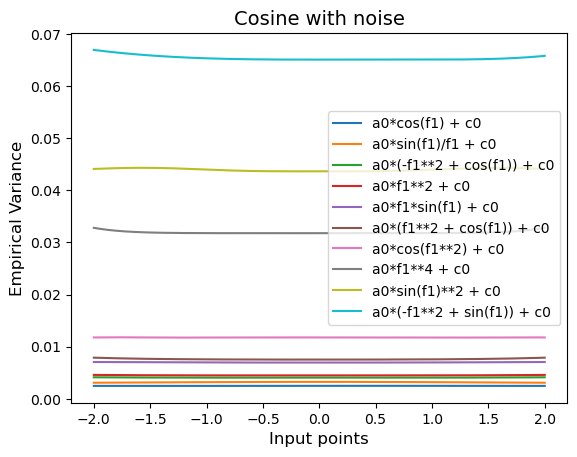

In [81]:
for i in range(models_stored):
    plt.plot(x, var_emp[:, i], label=fr'{sympy_exprs[i]}')
plt.legend()
plt.title('Cosine with noise', fontsize=14)
plt.xlabel('Input points', fontsize=12)
plt.ylabel('Empirical Variance', fontsize=12)
plt.show()

In [72]:
var_emp.shape #500

(700, 10)

In [84]:
# y_obs_train = np.tile(y_train, (10,1)).T
# y_obs_test = np.tile(y_test, (10,1)).T
# y_obs = np.vstack((y_obs_train, y_obs_test))
y_obs = np.tile(y, (10,1)).T

In [85]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.96678547, 0.87824437, 0.8430571 , 0.95433003, 0.96371143,
       0.93567626, 0.98566408, 0.9756076 , 0.94363939, 0.97176188])

$$
    R = \frac{1}{n_{features}} \sum_i^{n_{features}}\frac{ (y_i - \bar{y}_i)^2}{\sigma_i^2}
$$

If $R>1$ the system is overconfident otherwise if $R<1$ the system is underconfident.

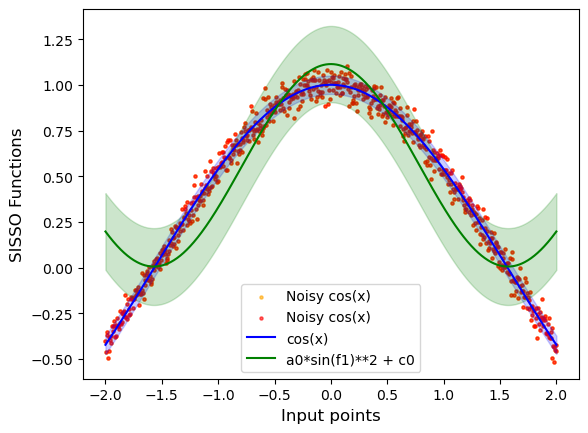

In [87]:
std = np.sqrt(var_emp)
plt.scatter(x, y, s=5, alpha=0.6, label='Noisy cos(x)', color='orange')
plt.scatter(x, y, s=5, alpha=0.6, label='Noisy cos(x)', color='red')
plt.plot(x, y_emp[:,0], label='cos(x)', color='blue')
plt.fill_between(x, y_emp[:,0] - std[:,0], y_emp[:,0] + std[:, 0], color='blue', alpha=0.2)
l = 8
plt.plot(x, y_emp[:,l], label=fr'{sympy_exprs[l]}', color='g')
plt.fill_between(x, y_emp[:,l] - std[:,l], y_emp[:,l] + std[:, l], color='g', alpha=0.2)
plt.legend()
plt.xlabel('Input points', fontsize=12)
plt.ylabel('SISSO Functions', fontsize=12)
#plt.title('Cosine with noise', fontsize=14)
#plt.savefig('cosine.pdf', bbox_inches='tight', dpi=600)
#plt.tick_params(axis='both', labelsize=12)
plt.show()